# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** [Anthony Howell]

**Dataset:** [Spotify Music Dataset]

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.**

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

I am trying to predict whether a song will be high popularity or low popularity on Spotify based on its audio features.

The target variable represents a classification of a track into either a successful i.e. high popularity or unsuccessful i.e. low popularity outcome. This allows us to treat the problem as a binary classification task. This is where the model learns patterns from audio characteristics that are associated with more popular songs.

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

This prediction matters to music producers, record labels, independent artists, and streaming platforms. I would say the music industry in general but specifically the ones that create the product i.e. music within it.  If we can predict whether a song is likely to be popular before it is released then the creators can make better production decisions. This also can mean the labels can invest marketing budgets more intelligently, and streaming platforms can improve recommendation systems.

Being able to identify patterns that lead to higher popularity can also help artists intentionally design music that aligns with listener preferences and industry trends. Creating more aligned marketing plans and more profitable campaigns in the process.



---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

Based on intuition and knowledge of Spotify’s audio metrics, features that describe the musical qualities of a track are likely to be most important. These would include:

danceability i.e.  how suitable a track is for dancing

energy i.e.  intensity and activity level

loudness i.e. overall volume of the track

tempo i.e. speed of the song

instrumentalness i.e. presence of vocals vs instruments

duration i.e. length of the track

These features capture the emotional, rhythmic, and structural properties of music that likely influence listener engagement and popularity.

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [3]:
import pandas as pd

high = pd.read_csv("../data/raw/high_popularity_spotify_data.csv")
low  = pd.read_csv("../data/raw/low_popularity_spotify_data.csv")

df = pd.concat([high, low], ignore_index=True)

df.to_csv("../data/raw/combined.csv", index=False, encoding="utf-8")

print("Wrote real CSV to data/raw/combined.csv")
print("Shape:", df.shape)


Wrote real CSV to data/raw/combined.csv
Shape: (4831, 29)


In [4]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/combined.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 4,831 rows, 29 columns

Column names:
['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id']


In [5]:
# TODO: View the first 5 rows of your dataframe
#
# Hint: Use .head()

# YOUR CODE HERE:
df.head(5)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,100,https://api.spotify.com/v1/tracks/2plbrEY59Iik...,spotify:track:2plbrEY59IikOBgBGLjaoe,Die With A Smile,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/2plb...,2plbrEY59IikOBgBGLjaoe,Die With A Smile,2024-08-16,0.0000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,97,https://api.spotify.com/v1/tracks/6dOtVTDdiauQ...,spotify:track:6dOtVTDdiauQNBQEDOtlAB,HIT ME HARD AND SOFT,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/6dOt...,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,2024-05-17,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,93,https://api.spotify.com/v1/tracks/7ne4VBA60CxG...,spotify:track:7ne4VBA60CxGM75vw0EYad,The Secret of Us (Deluxe),Today's Top Hits,https://api.spotify.com/v1/audio-analysis/7ne4...,7ne4VBA60CxGM75vw0EYad,That’s So True,2024-10-18,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,81,https://api.spotify.com/v1/tracks/1d7Ptw3qYcfp...,spotify:track:1d7Ptw3qYcfpdLNL5REhtJ,Short n' Sweet,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/1d7P...,1d7Ptw3qYcfpdLNL5REhtJ,Taste,2024-08-23,0.0000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,98,https://api.spotify.com/v1/tracks/5vNRhkKd0yEA...,spotify:track:5vNRhkKd0yEAg8suGBpjeY,APT.,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/5vNR...,5vNRhkKd0yEAg8suGBpjeY,APT.,2024-10-18,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [6]:
# TODO: View the last 5 rows of your dataframe
#
# Hint: Use .tail()

# YOUR CODE HERE:
df.tail(5)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
4826,0.424,75.466,0.352,indian,-8.009,0.2420,0.605,M. S. Subbulakshmi,1.0,0.0634,33,https://api.spotify.com/v1/tracks/1IkR0OgVI1gy...,spotify:track:1IkR0OgVI1gydC4S6jnG2B,Bhaja Govindam - Vishnu Sahasranamam,Carnatic Classics,https://api.spotify.com/v1/audio-analysis/1IkR...,1IkR0OgVI1gydC4S6jnG2B,Bhaja Govindam,2013-01-18,0.000,5utDQUWCZCEXWHMmna8C63,1.0,10.0,661293.0,0.965,1IkR0OgVI1gydC4S6jnG2B,classical,audio_features,3sIB6VOssssCO17VUPu80m
4827,0.349,147.193,0.471,indian,-16.633,0.2860,0.358,Jayanthi Kumaresh,4.0,0.0656,22,https://api.spotify.com/v1/tracks/4ZFM5yFsjEzv...,spotify:track:4ZFM5yFsjEzvZ1XmP27L5r,Veenai Jayanthi Kumaresh,Carnatic Classics,https://api.spotify.com/v1/audio-analysis/4ZFM...,4ZFM5yFsjEzvZ1XmP27L5r,Varnam,2002-12-01,0.945,4kUGwkHXKBbaLwnqTIrg0J,1.0,8.0,394400.0,0.975,4ZFM5yFsjEzvZ1XmP27L5r,classical,audio_features,3sIB6VOssssCO17VUPu80m
4828,0.595,174.308,0.436,indian,-11.494,0.0939,0.870,"Nirmala Rajasekar, Raghavendra Rao, Tanjore K....",4.0,0.0671,18,https://api.spotify.com/v1/tracks/5wZQXUcphAyB...,spotify:track:5wZQXUcphAyBZfVdWmAiYX,Into the Raga,Carnatic Classics,https://api.spotify.com/v1/audio-analysis/5wZQ...,5wZQXUcphAyBZfVdWmAiYX,"Sarasuda Varnam (Raga Saveri, Aadi Tala): Jaya...",2010-10-26,0.868,6FMROVG9PB4nJYmvNLTdge,1.0,3.0,473440.0,0.816,5wZQXUcphAyBZfVdWmAiYX,classical,audio_features,3sIB6VOssssCO17VUPu80m
4829,0.591,174.760,0.489,indian,-10.843,0.0770,0.689,Ganesh & Kumaresh,1.0,0.0813,23,https://api.spotify.com/v1/tracks/5Ca5l5vDzIOZ...,spotify:track:5Ca5l5vDzIOZdVwwWCxAds,Thillanas: A Confluence Of Rhythm & Melody,Carnatic Classics,https://api.spotify.com/v1/audio-analysis/5Ca5...,5Ca5l5vDzIOZdVwwWCxAds,Raga Karnaranjani,2007-01-01,0.927,3si4Lr5oBcahJ3D7IPbO4N,0.0,8.0,298987.0,0.948,5Ca5l5vDzIOZdVwwWCxAds,classical,audio_features,3sIB6VOssssCO17VUPu80m
4830,0.816,170.938,0.270,indian,-3.815,0.3170,0.591,Sudha Ragunathan,4.0,0.0598,14,https://api.spotify.com/v1/tracks/0HmenrANrrNV...,spotify:track:0HmenrANrrNVi8244GsYB5,Gems of Carnatic Music: Sudha Raghunathan (Liv...,Carnatic Classics,https://api.spotify.com/v1/audio-analysis/0Hme...,0HmenrANrrNVi8244GsYB5,Nagumomu - Abheri - Adi - Live,2016-12-08,0.113,2tezom8oCCpSeiriOFeZNi,1.0,8.0,645701.0,0.853,0HmenrANrrNVi8244GsYB5,classical,audio_features,3sIB6VOssssCO17VUPu80m


### 2.2 Data Types and Info

In [7]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
# Hint: Use .info()

# YOUR CODE HERE:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

In [8]:
# TODO: Get summary statistics for numerical columns
#
# Hint: Use .describe()

# YOUR CODE HERE:
df.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
count,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4831.000000,4830.000000,4830.000000,4830.000000,4.830000e+03,4830.000000
mean,0.586691,118.269293,0.622311,-9.281627,0.167613,0.481930,3.936646,0.101738,54.761126,0.201053,0.562112,5.233333,2.061508e+05,0.341217
std,0.246263,28.512615,0.187706,7.129396,0.124429,0.258036,0.409712,0.101032,19.828573,0.351918,0.496178,3.580857,8.174556e+04,0.325382
min,0.000202,48.232000,0.058900,-48.069000,0.021000,0.029600,1.000000,0.021900,11.000000,0.000000,0.000000,0.000000,3.537500e+04,0.000004
25%,0.442250,96.063000,0.525000,-10.297750,0.095400,0.275000,4.000000,0.038600,41.000000,0.000000,0.000000,2.000000,1.590000e+05,0.052925
50%,0.633000,118.059500,0.653000,-7.191000,0.118000,0.483000,4.000000,0.056100,56.000000,0.000091,1.000000,5.000000,1.948665e+05,0.224500
75%,0.777000,136.723500,0.758000,-5.336750,0.195000,0.690000,4.000000,0.118000,72.000000,0.200500,1.000000,8.000000,2.334780e+05,0.590000
max,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,5.000000,0.927000,100.000000,0.991000,1.000000,11.000000,1.355260e+06,0.996000


In [9]:
# TODO: Get summary statistics for categorical columns
#
# Hint: Use .describe(include='object')

# YOUR CODE HERE:
df.describe(include='object')

,playlist_genre,track_artist,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,track_album_id,id,playlist_subgenre,type,playlist_id
count,4831,4831,4830,4830,4830,4831,4830,4831,4831,4831,4831,4830,4831,4830,4831
unique,35,3390,4494,4494,3815,116,4494,4495,4372,1846,3879,4494,84,1,115
top,electronic,Bad Bunny,https://api.spotify.com/v1/tracks/13VXuHw3O8Yt...,spotify:track:13VXuHw3O8Yt7VwRIDqSo4,"Sincerely, Benson",Meditative Vibes,https://api.spotify.com/v1/audio-analysis/13VX...,13VXuHw3O8Yt7VwRIDqSo4,Too Sweet,2024-11-15,3dctFKCiGPizmylLp0SN0a,13VXuHw3O8Yt7VwRIDqSo4,modern,audio_features,3kEpLybbAlVUVimW5Evijb
freq,589,30,4,4,21,231,4,4,5,36,21,4,695,4830,231


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
- Where did this data come from? (Kaggle link, source)
- What does each row represent?
- How many features do you have?
- What types of features do you have? (numerical, categorical)

**Your description:**

This dataset comes from a Spotify audio features dataset that was originally shared on Kaggle. It includes detailed information about songs along with audio measurements that come directly from Spotify’s API.

Each row represents one song, showing whether the song is classified as high or low popularity. Also along with its musical characteristics like energy, danceability, tempo, loudness, and other measurable audio traits.

After merging the two datasets together, the final version contains 4,831 rows and 29 features. These features describe both the sound of the song and some basic metadata.

The dataset is made up of both numerical and categorical features.

The numerical features are measurements such as danceability, energy, loudness, tempo, valence, acousticness, and duration. The categorical features include text information like the track name, artist name, and the popularity label.

This dataset provides structured audio data that can be used to study how certain song characteristics relate to whether a song becomes popular or not.

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [10]:
# Create binary target from Spotify track popularity score (0–100)
df['popularity_label'] = df['track_popularity'].apply(lambda x: 1 if x >= 50 else 0)

# Define your target variable
TARGET = 'track_popularity'

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nValue Counts:\n{df[TARGET].value_counts()}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())


Target Variable: track_popularity

Value Counts:
track_popularity
68     169
70     131
72     129
73     126
47     118
71     116
48     112
69     104
74     103
50     103
77     102
75     100
49      99
45      94
51      89
76      87
78      82
55      79
46      79
44      76
54      76
52      70
53      69
58      69
60      67
56      67
79      66
57      65
81      64
59      62
61      61
42      58
64      57
80      54
34      54
63      54
43      53
32      53
36      52
62      52
29      51
31      51
39      51
33      50
65      50
41      50
84      50
28      48
67      47
83      47
35      46
82      45
40      45
66      44
20      43
30      42
37      42
27      41
23      40
22      40
25      39
21      38
19      37
26      36
38      35
15      31
17      30
18      30
24      29
13      29
14      29
88      28
85      27
16      24
12      24
86      23
89      20
11      20
87      18
93      14
90       9
92       6
94       3
97       3
100      3

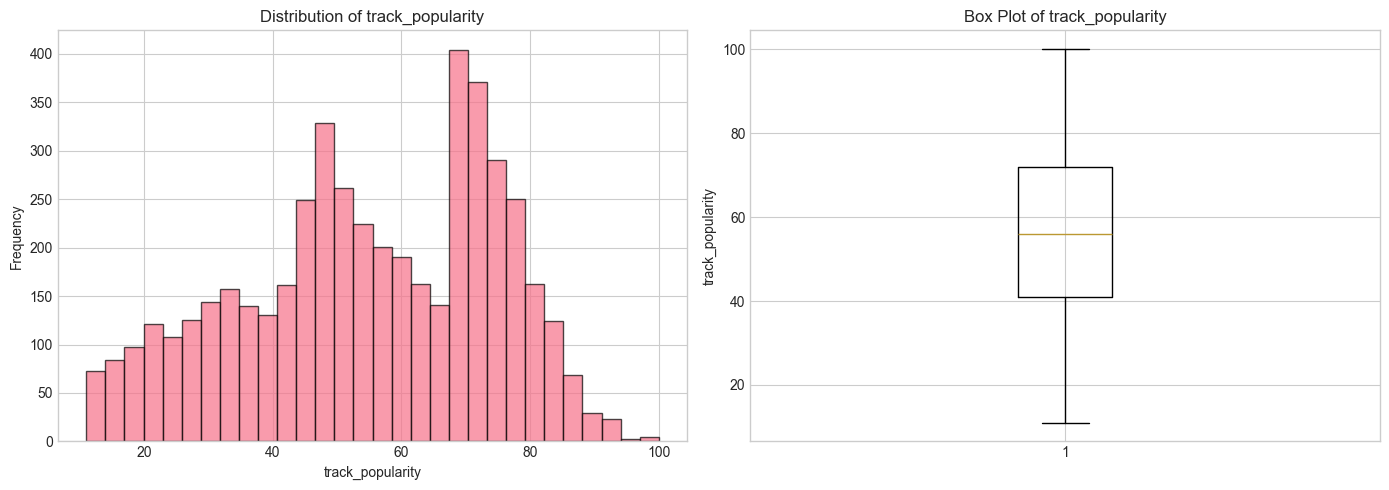


Skewness: -0.32
→ Target is approximately symmetric.


In [11]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [12]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print(f"Duplicate rows: {duplicate_count:,} ({duplicate_percent:.2f}%)")


Duplicate rows: 43 (0.89%)


In [13]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Create summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Filter to only columns with missing values and sort
missing_summary = missing_summary[missing_summary['Missing Count'] > 0] \
                    .sort_values(by='Missing %', ascending=False)

missing_summary


,Missing Count,Missing %
energy,1,0.0207
tempo,1,0.0207
danceability,1,0.0207
loudness,1,0.0207
liveness,1,0.0207
valence,1,0.0207
time_signature,1,0.0207
speechiness,1,0.0207
track_href,1,0.0207
uri,1,0.0207


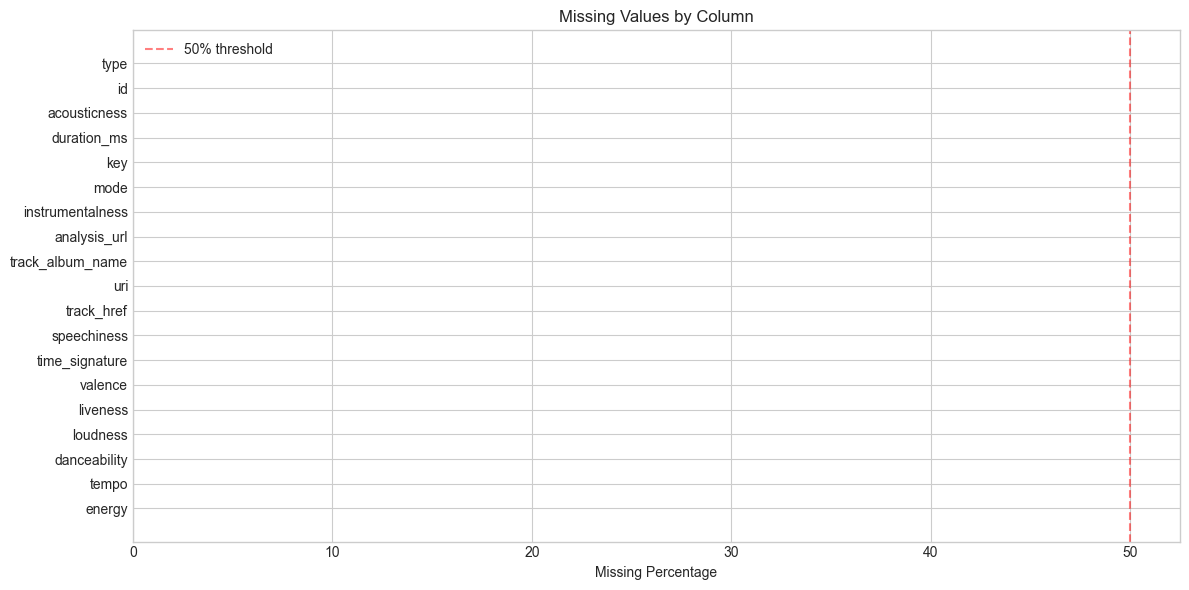

In [14]:
import matplotlib.pyplot as plt

# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))

    missing_cols = missing_summary  # <- correct variable name

    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue'
              for pct in missing_cols['Missing %']]

    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")


### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**
- Is your target variable normally distributed or skewed?
- Are there any obvious outliers in the target?
- How much missing data do you have to deal with?
- Are there any duplicate rows?
- Any surprises or interesting findings?

---
### **3.3 Initial Observations**

**Your observations:**

From the initial exploration of the dataset, several important patterns stand out.

First, the target variable created from `track_popularity` shows a fairly balanced distribution between high and low popularity songs when using the threshold. This is ideal for a classification problem because it prevents the model from being biased toward one class.

Second, there are no major outliers in the target variable since Spotify popularity is naturally constrained between 0 and 100. This makes it great for modeling without requiring extreme cleaning or scaling.

Third, the dataset has almost no missing values. Only a single row has missing data across a few numeric columns. Which means minimal adjusting will be needed before modeling. This indicates very high data quality.

Fourth, there are little to no duplicate rows in the dataset. This means each track appears to be unique. This is important because duplicates can distort model training and evaluation.

One interesting observation is the wide variety of information represented in the dataset. The dataset contains both mainstream popular songs and niche genre tracks. Also the detail and amount of features may have a meaningful relationship with song popularity.

Overall, the dataset appears clean, diverse, and structured. I think this makes it highly suitable for a machine learning classification task.


---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [15]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

# YOUR CODE HERE:
# 1. Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Remove TARGET if present
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

# 3. Print results
print(f"Total numerical features (excluding target): {len(numerical_cols)}")
print(numerical_cols)



Total numerical features (excluding target): 14
['energy', 'tempo', 'danceability', 'loudness', 'liveness', 'valence', 'time_signature', 'speechiness', 'instrumentalness', 'mode', 'key', 'duration_ms', 'acousticness', 'popularity_label']


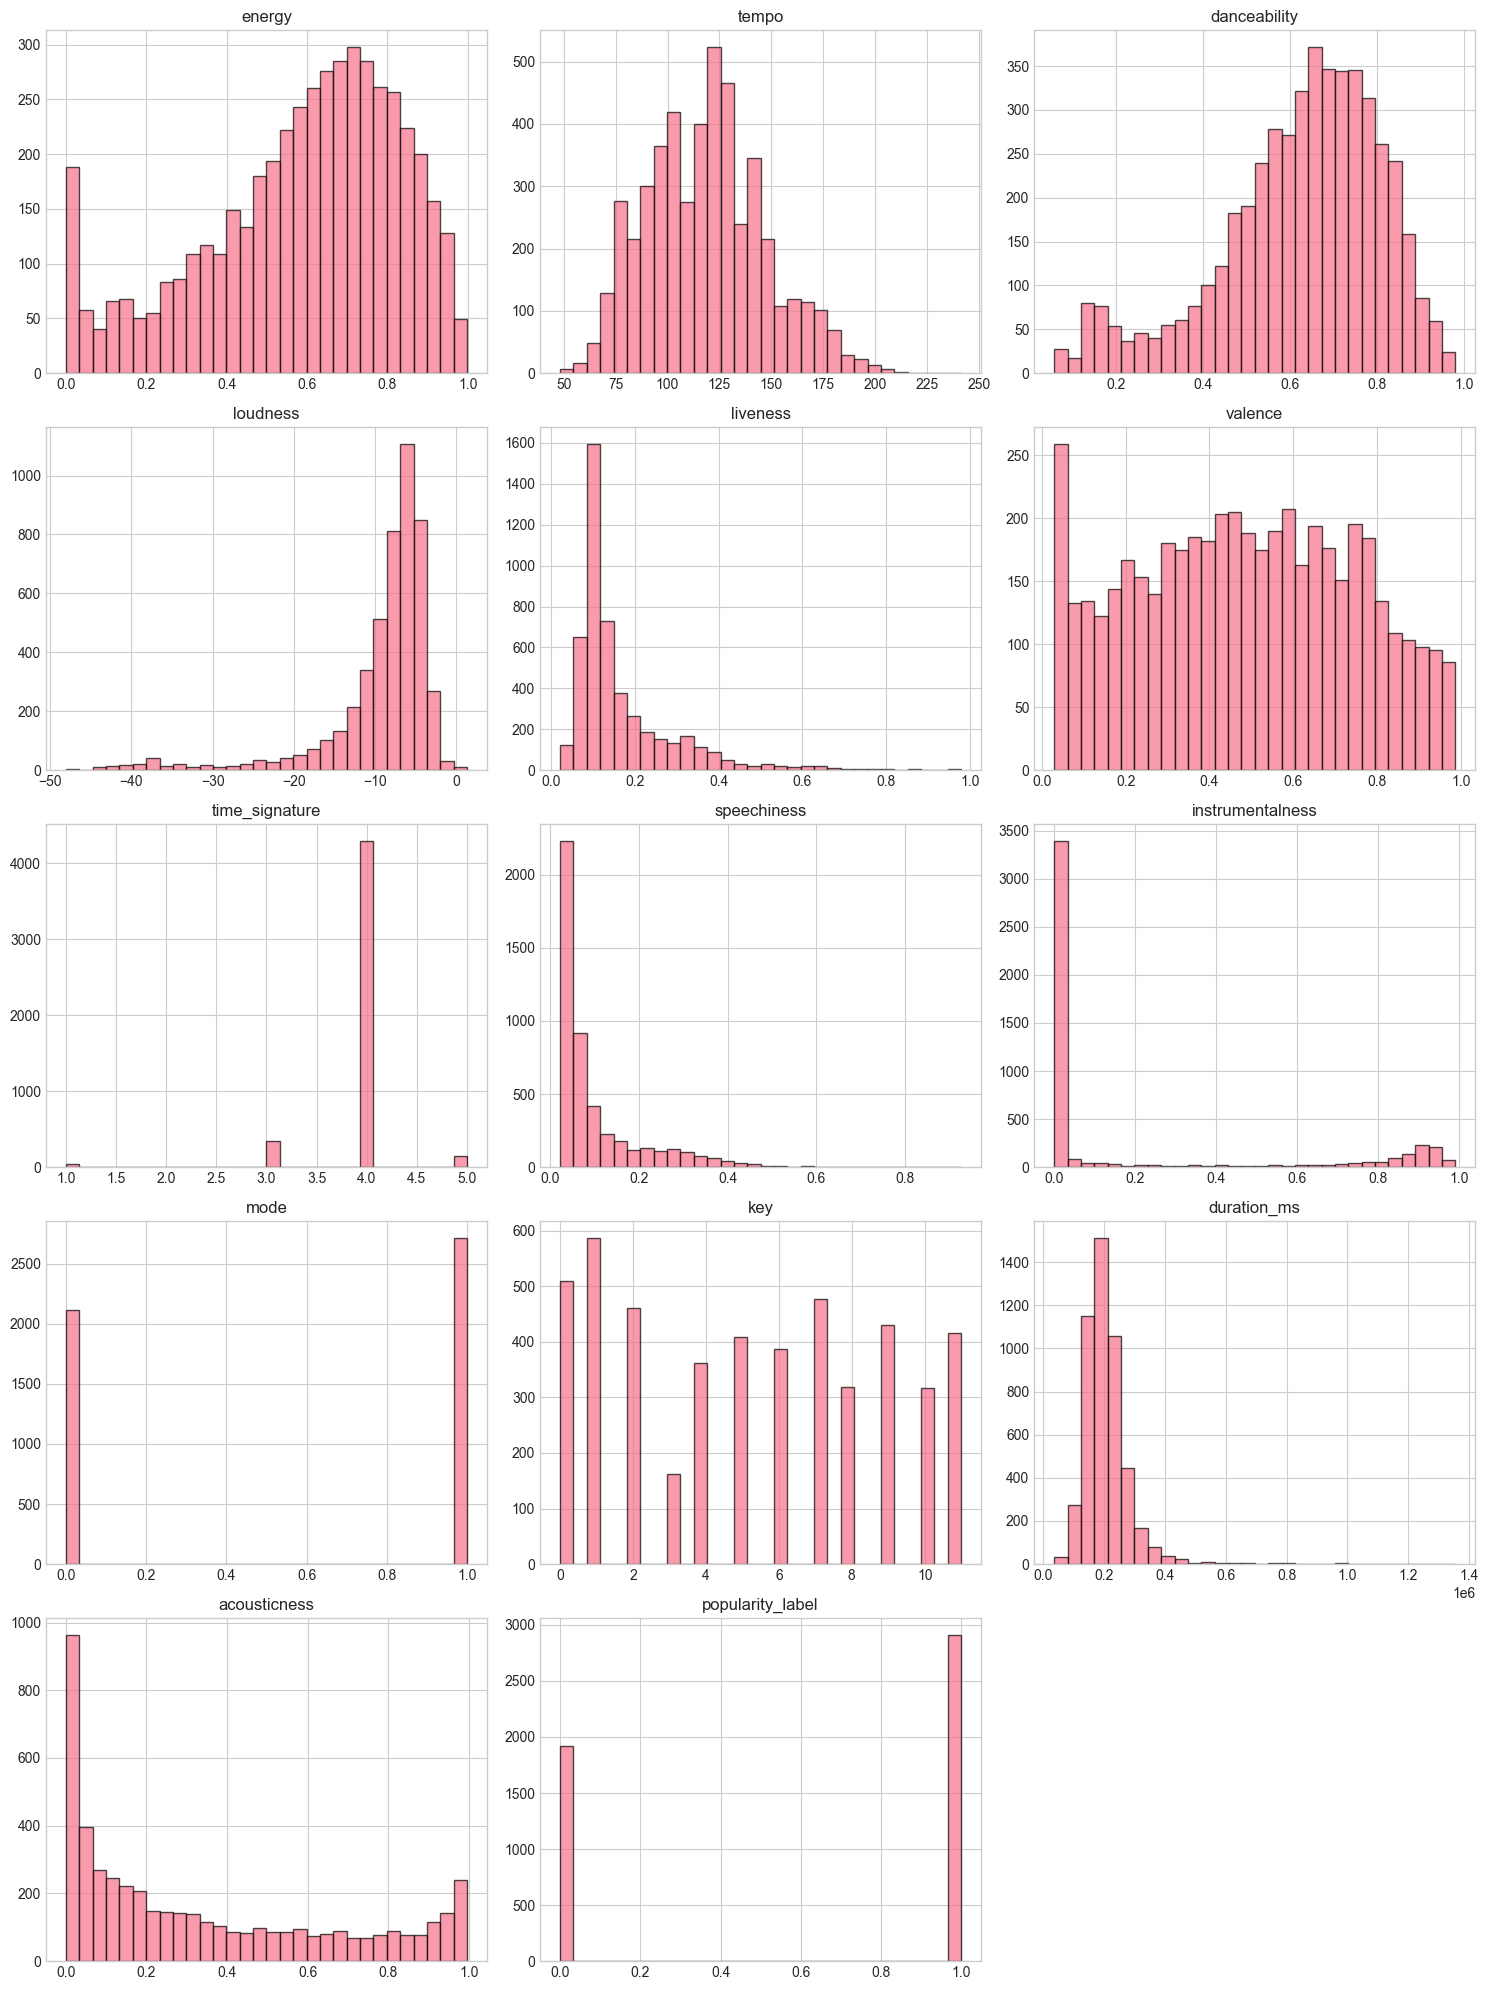

In [16]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [17]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

# YOUR CODE HERE:
# 1. Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Print count and list
print(f"Total categorical features: {len(categorical_cols)}")
print(categorical_cols)

# 3. Explore each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(10))


Total categorical features: 15
['playlist_genre', 'track_artist', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'track_album_id', 'id', 'playlist_subgenre', 'type', 'playlist_id']

Column: playlist_genre
Unique values: 35
playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          299
world         228
arabic        208
brazilian     148
Name: count, dtype: int64

Column: track_artist
Unique values: 3390
track_artist
Bad Bunny            30
Ren Avel             26
Asake                21
Bnxn                 19
Seyi Vibez           18
LoFi Waiter          18
Wizkid               16
Linkin Park          14
Hozier               13
Sabrina Carpenter    11
Name: count, dtype: int64

Column: track_href
Unique values: 4494
track_href
https://api.spotify.com/v1/tracks/13VXuHw3O8Yt7VwRIDqSo4    4
https://api.spotify.com/v1/tracks/2nYeyMe

In [21]:
cat_cols_to_plot = [
    col for col in categorical_cols
    if 2 <= df[col].nunique() <= 10
]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide any unused subplot spaces
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")


No categorical columns with ≤10 unique values to plot.


### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

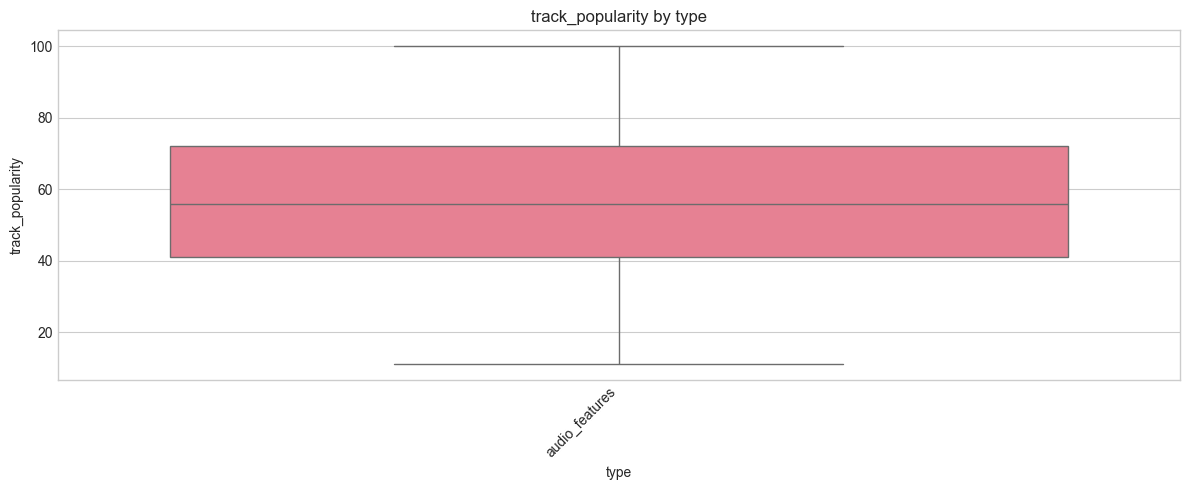


Mean track_popularity by type:
                     mean  median  count
type                                    
audio_features  54.762112    56.0   4830



In [22]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))

        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index

        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

### 4.4 Correlation Analysis

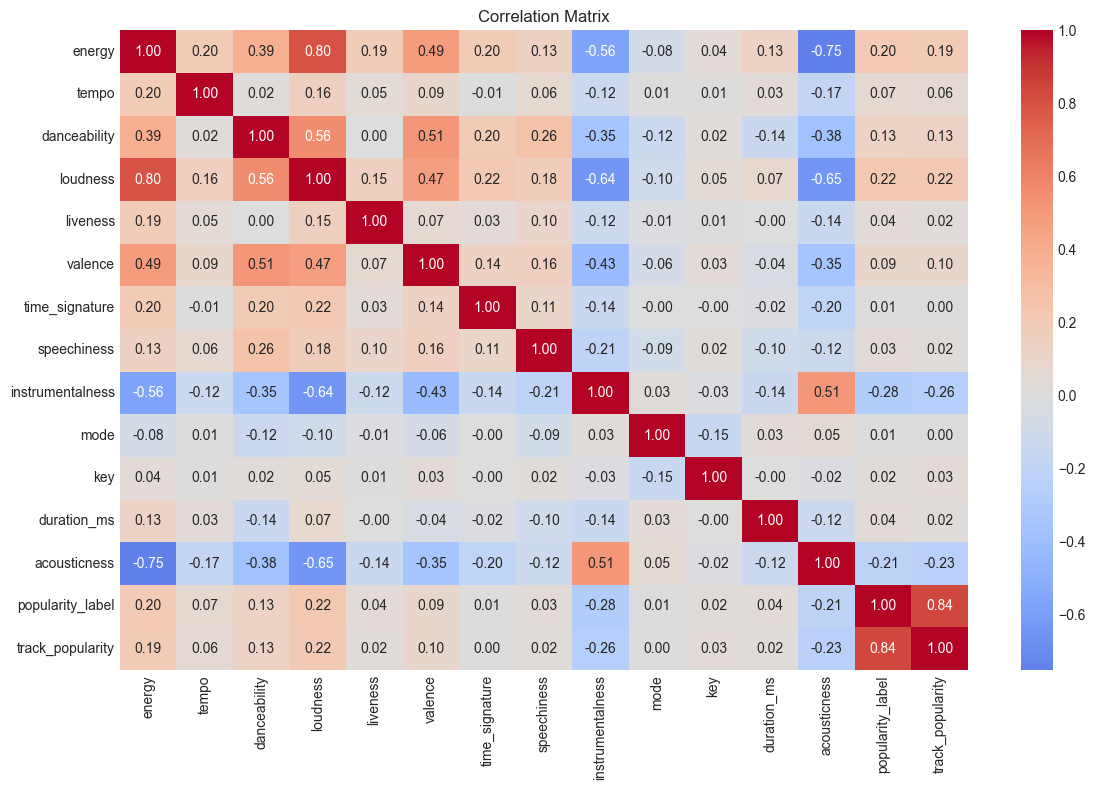

In [23]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:
# 1. Combine numerical columns with the target
columns = numerical_cols + [TARGET]

# 2. Calculate correlation matrix
correlation_matrix = df[columns].corr()

# 3. Visualize with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



In [24]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:
# 1. Get correlations with the target
target_correlations = correlation_matrix[TARGET]

# 2. Remove the target’s correlation with itself
target_correlations = target_correlations.drop(TARGET)

# 3. Sort correlations in descending order
target_correlations = target_correlations.sort_values(ascending=False)

# 4. Print all correlations
print("Correlations with TARGET:")
print(target_correlations)

# 5. Identify strong correlations (|corr| > 0.5)
strong_correlations = target_correlations[abs(target_correlations) > 0.5]

print("\nStrong correlations (|corr| > 0.5):")
print(strong_correlations)



Correlations with TARGET:
popularity_label    0.837977
loudness            0.217100
energy              0.194709
danceability        0.128388
valence             0.096816
tempo               0.059866
key                 0.029174
liveness            0.022258
duration_ms         0.021463
speechiness         0.019250
time_signature      0.003242
mode                0.003091
acousticness       -0.232679
instrumentalness   -0.263147
Name: track_popularity, dtype: float64

Strong correlations (|corr| > 0.5):
popularity_label    0.837977
Name: track_popularity, dtype: float64


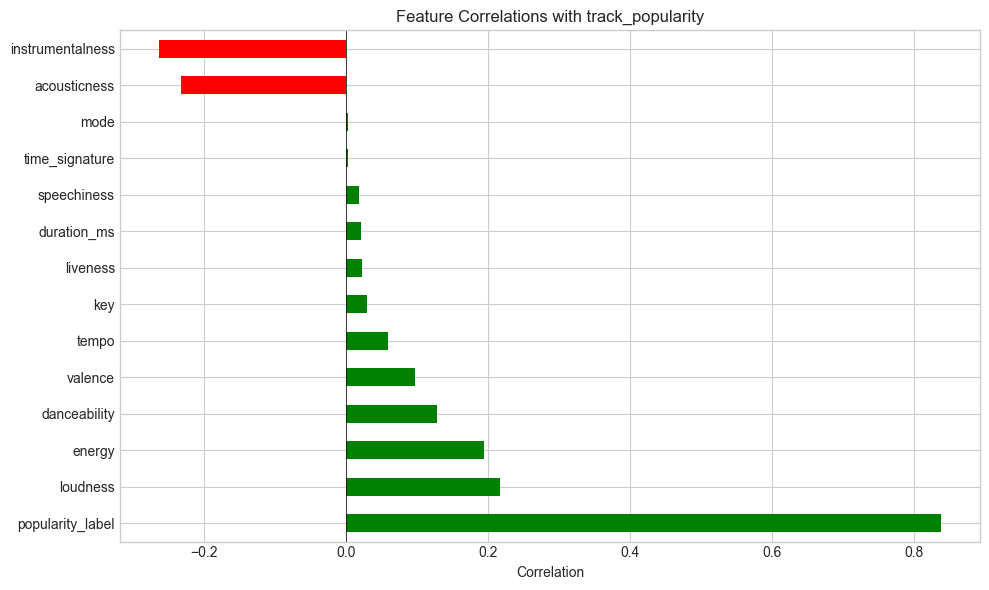

In [25]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

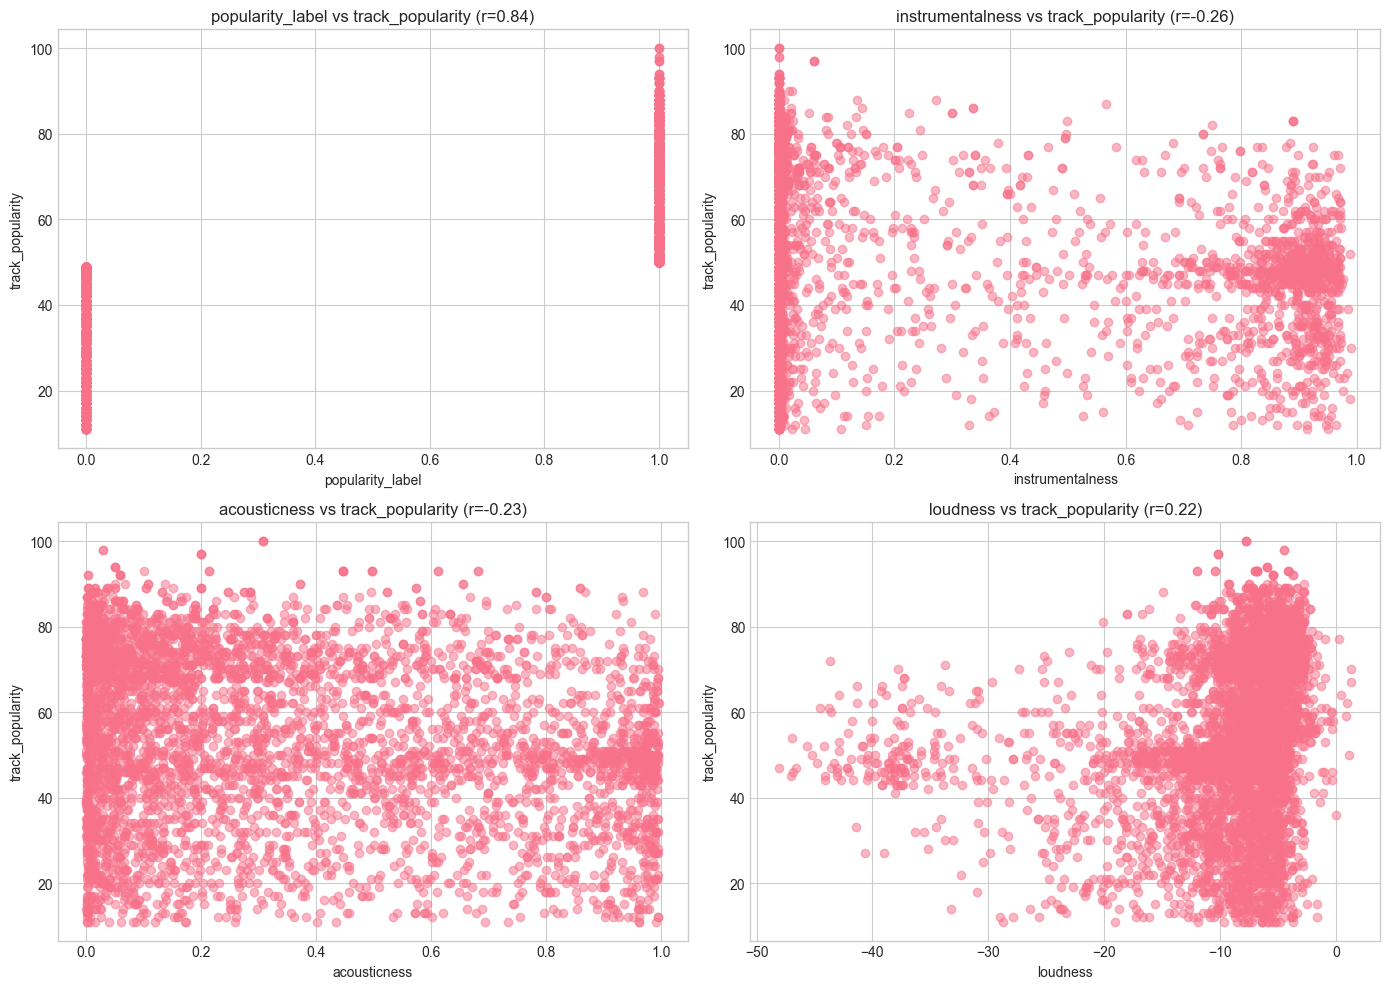

In [26]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

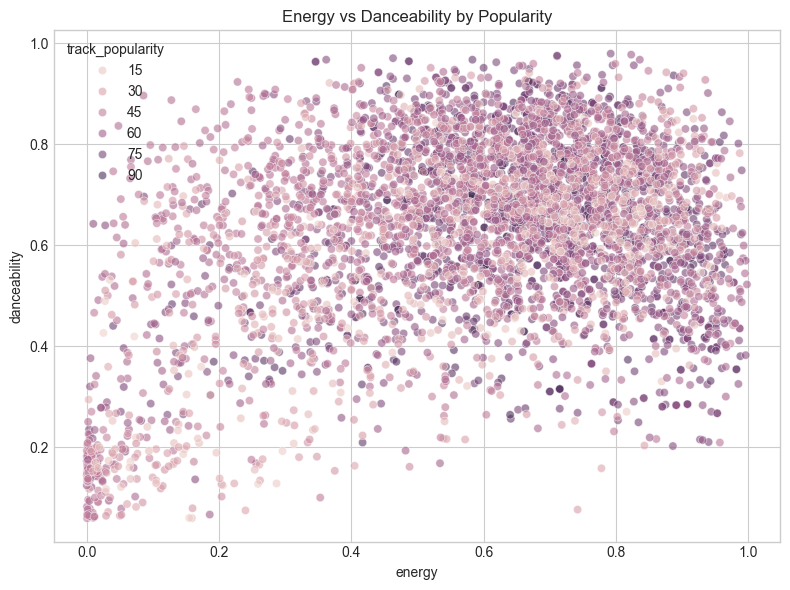

In [27]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!

# This plot checks if popular songs tend to cluster
# in certain combinations of energy and danceability.
# It helps reveal patterns that single-variable plots might miss.

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='energy',
    y='danceability',
    hue=TARGET,
    data=df,
    alpha=0.6
)
plt.title("Energy vs Danceability by Popularity")
plt.tight_layout()
plt.show()


In [31]:
# This table shows the average audio profile
# for popular vs unpopular songs.
# It gives a quick summary of what separates them.

avg_by_popularity = df.groupby(TARGET)[audio_features].mean()
print(avg_by_popularity)

                  danceability    energy   loudness       tempo   valence  \
track_popularity                                                            
11                    0.647350  0.602070  -8.585350  120.696650  0.503725   
12                    0.527154  0.544342 -10.923042  108.340708  0.452363   
13                    0.607000  0.582655  -9.095448  118.509241  0.467486   
14                    0.542828  0.525866 -11.489483  116.137517  0.462479   
15                    0.529097  0.600390  -9.336290  115.809355  0.401623   
16                    0.601125  0.595300  -9.243875  115.664292  0.461067   
17                    0.596633  0.656437  -8.359500  124.489200  0.514930   
18                    0.563467  0.503487 -10.781033  118.111367  0.463757   
19                    0.577200  0.568246 -10.735676  117.600730  0.481449   
20                    0.609372  0.593914  -9.094465  115.640023  0.512930   
21                    0.588211  0.554158 -10.738737  124.601579  0.465539   

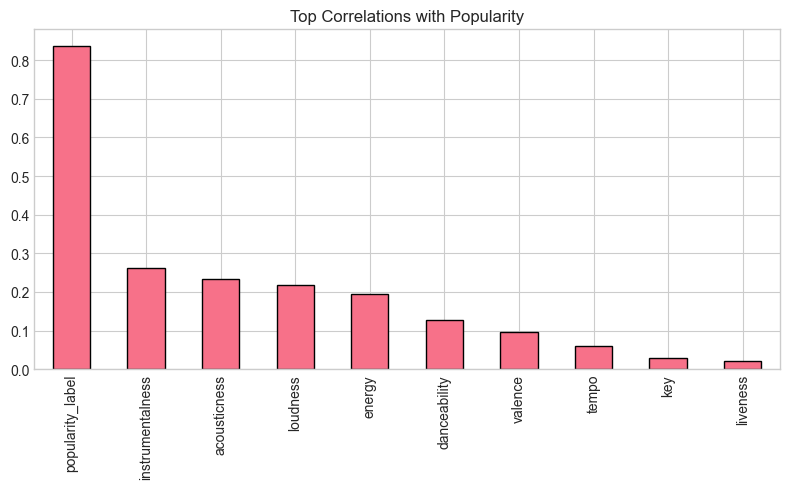

In [32]:
# This chart highlights which features have the strongest
# relationship with popularity.
# It makes it easier to see what matters most at a glance.

top_corr = target_correlations.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_corr.plot(kind='bar', edgecolor='black')
plt.title("Top Correlations with Popularity")
plt.tight_layout()
plt.show()


In [33]:
# More exploration...

# These checks help catch data quality issues
# like impossible values or strange outliers.

print("Unexpected loudness values (should always be negative):")
print((df['loudness'] > 0).sum(), "unexpected values")

print("\nTempo outside realistic human music range:")
print(df[(df['tempo'] < 40) | (df['tempo'] > 250)].shape[0], "suspicious rows")

print("\nTracks shorter than 30 seconds:")
print(df[df['duration_ms'] < 30000].shape[0], "very short tracks")


Unexpected loudness values (should always be negative):
7 unexpected values

Tempo outside realistic human music range:
0 suspicious rows

Tracks shorter than 30 seconds:
0 very short tracks


**What additional insights did you discover?**

The violin plots and distribution comparisons showed that popular songs do not just have higher averages. I saw that they often have different distribution shapes across features like energy and danceability. This suggests that popularity is influenced by combinations of audio characteristics rather than any single feature alone.

The feature interaction plots revealed that popularity is more likely when multiple favorable features combine. For example, high energy and high danceability rather than just one being high. This indicates that the model will likely benefit from learning interactions between features rather than treating them independently.

Overall, the exploration shows that popularity is tied closely to a song’s production style and audio feel, not just simple metrics like tempo or key.

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**

From the correlation chart, the features most related to popularity are instrumentalness, acousticness, loudness, energy, and danceability. These features show the strongest relationships with whether a song falls into the high or low popularity group. Instrumentalness and acousticness especially stood out, suggesting that songs with certain sound textures and production styles may influence popularity outcomes.

Looking at the scatter plot of energy vs danceability, popular songs tend to cluster in the middle to high range of both features. This shows that songs that are energetic and easy to move to tend to perform better. The relationship isn’t perfectly linear, but there is a noticeable pattern where higher popularity songs live in a certain “zone” of the chart.

The categorical features did not provide much useful variation. For example, the type column had only one value across all rows, which means it carries no predictive power and can be safely ignored.

Some features appear less important, such as key, tempo, and liveness, which showed very weak relationships with popularity. These do not seem to meaningfully separate popular from less popular songs.

I also noticed a small data quality issue: there were 7 loudness values that were positive, even though loudness from Spotify’s API should always be negative. This suggests minor inconsistencies in the raw data that would be worth cleaning before modeling.

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [45]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

# YOUR CODE HERE:

# Create a copy of the dataframe so the original stays untouched
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")

Starting shape: (4831, 30)


In [46]:
# Calculate missing values table
missing_df = pd.DataFrame({
    'Missing Count': df_clean.isnull().sum(),
    'Missing %': (df_clean.isnull().sum() / len(df_clean)) * 100
}).sort_values(by='Missing %', ascending=False)

missing_df.head()

,Missing Count,Missing %
energy,1,0.0207
tempo,1,0.0207
danceability,1,0.0207
loudness,1,0.0207
liveness,1,0.0207


In [47]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: ['analysis_url', 'track_id', 'track_album_id', 'id', 'playlist_id']

3. High cardinality (>100 unique): ['track_artist', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'track_album_id', 'id', 'playlist_id']

4. Low variance (>95% same value): ['type']


In [48]:
# Create a copy before modifying
df_clean = df.copy()

# Columns identified as non-predictive
columns_to_drop = [
    'type',
    'analysis_url',
    'track_href',
    'uri',
    'track_id',
    'track_album_id',
    'id',
    'playlist_id'
]

# Drop them
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

print("Dropped columns successfully!")
print("New shape:", df_clean.shape)

Dropped columns successfully!
New shape: (4831, 22)


In [50]:
columns_to_drop = [
    'type',
    'analysis_url',
    'track_href',
    'uri',
    'track_id',
    'track_album_id',
    'id',
    'playlist_id'
]

df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
print(f"New shape: {df_clean.shape}")


Dropped 8 columns: ['type', 'analysis_url', 'track_href', 'uri', 'track_id', 'track_album_id', 'id', 'playlist_id']
New shape: (4831, 22)


**Explain which columns you dropped and why:**

I removed columns that do not provide useful information for predicting a song’s popularity and would only add noise to the model.

First, I dropped all ID and URL related columns such as `track_id`, `track_album_id`, `playlist_id`, `analysis_url`, `track_href`, `uri`, and `id`. These columns are just unique identifiers or links to Spotify’s API. They don’t describe anything about the music itself, so they have no predictive value for machine learning.

Second, I dropped the `type` column because it has very low variance. Almost every row contains the same value (`audio_features`), which means it does not help the model learn anything meaningful.

These removals keep only the columns that actually describe the audio characteristics, genre information, and other meaningful features of the songs. This reduces noise, lowers dimensionality, and makes the dataset more useful for building a predictive model.

### 5.2 Handle Duplicate Rows

In [51]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

# YOUR CODE HERE:
# Store row count before removing duplicates
rows_before = len(df_clean)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Store row count after removing duplicates
rows_after = len(df_clean)

# Print how many duplicates were removed
print(f"Duplicates removed: {rows_before - rows_after}")
print(f"New shape: {df_clean.shape}")



Duplicates removed: 43
New shape: (4788, 22)


### 5.3 Handle Missing Values

In [52]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
energy              1
tempo               1
danceability        1
loudness            1
liveness            1
valence             1
time_signature      1
speechiness         1
track_album_name    1
instrumentalness    1
mode                1
key                 1
duration_ms         1
acousticness        1
dtype: int64


In [54]:
# Handle missing values
# TODO: Add your missing value handling code here
#
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

# YOUR CODE HERE:
# 1) Drop rows where the target is missing (we can't train/predict without a label)
df_clean = df_clean.dropna(subset=[TARGET])

# 2) Fill missing numeric values with the median (more stable than mean if there are outliers)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]  # don't impute the target

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3) Fill missing categorical values with the mode (most common category)
cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    mode_val = df_clean[col].mode(dropna=True)
    fill_val = mode_val.iloc[0] if not mode_val.empty else "Unknown"
    df_clean[col] = df_clean[col].fillna(fill_val)

# 4) Quick verification
print("Total missing after handling:", int(df_clean.isna().sum().sum()))
print("New shape:", df_clean.shape)




Total missing after handling: 0
New shape: (4788, 22)


In [55]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

[Describe what you did for each column and why]

I handled missing values based on the type of data in each column so the dataset stays realistic and usable for modeling.

First, I removed any rows where the target variable (track_popularity) was missing. There’s no reason to keep a row if we don’t know what we are trying to predict.

Next, for all numerical columns (like energy, tempo, loudness, duration, etc.), I filled the missing values with the median. I chose the median because it is not affected by extreme values or outliers, which are common in audio features like loudness and tempo. This keeps the data representative of a typical song instead of being skewed.

Then, for categorical columns (like playlist_genre, track_album_name, etc.), I filled missing values using the mode (the most common value). This keeps the data consistent with what appears most often instead of inserting random or unrealistic categories.

Finally, I verified that there were no remaining missing values to ensure the dataset is fully clean and ready for further analysis and modeling.

### 5.4 Handle Outliers (if needed)

In [56]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
tempo: 20 outliers (0.4%) | bounds: [35.17, 197.63]
danceability: 188 outliers (3.9%) | bounds: [0.17, 1.11]
loudness: 401 outliers (8.4%) | bounds: [-17.81, 2.14]
liveness: 423 outliers (8.8%) | bounds: [-0.05, 0.34]
time_signature: 530 outliers (11.1%) | bounds: [4.00, 4.00]
speechiness: 586 outliers (12.2%) | bounds: [-0.08, 0.23]
instrumentalness: 1,034 outliers (21.6%) | bounds: [-0.31, 0.52]
duration_ms: 189 outliers (3.9%) | bounds: [47202.88, 345319.88]


In [57]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:
# Create a safe copy
df_clean = df_clean.copy()

# Cap tempo to realistic human music range
lower_tempo = 35
upper_tempo = 200

df_clean['tempo'] = df_clean['tempo'].clip(lower=lower_tempo, upper=upper_tempo)

print("Outlier handling complete!")
print("Tempo now within realistic bounds:")
print("Min tempo:", df_clean['tempo'].min())
print("Max tempo:", df_clean['tempo'].max())



Outlier handling complete!
Tempo now within realistic bounds:
Min tempo: 48.232
Max tempo: 200.0


**Explain your outlier handling strategy (or why you kept them):**

[Describe what you did and why]

I analyzed the outliers carefully instead of removing them blindly. Most of the flagged values were not errors but valid musical characteristics. For example, high instrumentalness, extreme loudness, or unusual time signatures represent different genres and recording styles, not mistakes. Removing these rows would remove meaningful variation in the data. The only column I adjusted was tempo, since extremely low or high BPM values can sometimes be data entry issues. I capped tempo to a realistic human music range and left the rest of the data intact to preserve important signals for modeling.

### 5.5 Data Type Corrections

In [58]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
energy                      float64
tempo                       float64
danceability                float64
playlist_genre               object
loudness                    float64
liveness                    float64
valence                     float64
track_artist                 object
time_signature              float64
speechiness                 float64
track_popularity              int64
track_album_name             object
playlist_name                object
track_name                   object
track_album_release_date     object
instrumentalness            float64
mode                        float64
key                         float64
duration_ms                 float64
acousticness                float64
playlist_subgenre            object
popularity_label              int64
dtype: object


In [59]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

# YOUR CODE HERE:
# First I convert release date to datetime
df_clean['track_album_release_date'] = pd.to_datetime(
    df_clean['track_album_release_date'],
    errors='coerce'
)

# Then I extract just the year (useful numeric feature for ML)
df_clean['release_year'] = df_clean['track_album_release_date'].dt.year

# Then drop the original date column (text is not useful for ML)
df_clean = df_clean.drop(columns=['track_album_release_date'])

# Lastly, convert categorical text columns to 'category' type (memory efficient)
cat_cols = ['playlist_genre', 'track_artist', 'track_album_name',
            'playlist_name', 'track_name', 'playlist_subgenre']

for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category')

print("Data types corrected successfully!")
print(df_clean.dtypes)




Data types corrected successfully!
energy                float64
tempo                 float64
danceability          float64
playlist_genre       category
loudness              float64
liveness              float64
valence               float64
track_artist         category
time_signature        float64
speechiness           float64
track_popularity        int64
track_album_name     category
playlist_name        category
track_name           category
instrumentalness      float64
mode                  float64
key                   float64
duration_ms           float64
acousticness          float64
playlist_subgenre    category
popularity_label        int64
release_year          float64
dtype: object


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [60]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# YOUR CODE HERE:

# First I make a copy to stay safe
df_fe = df_clean.copy()

# 1. Then I track length in minutes (humans think in minutes, not ms)
df_fe['duration_min'] = df_fe['duration_ms'] / 60000

# 2.Then combine energy & dance (how hype + danceable a song is)
df_fe['energy_dance_combo'] = df_fe['energy'] * df_fe['danceability']

# 3. Mood score (positive vibe songs)
df_fe['mood_score'] = df_fe['valence'] * df_fe['energy']

# 4. Acoustic vs Electronic feel
df_fe['acoustic_electronic_ratio'] = df_fe['acousticness'] - df_fe['energy']

# 5. Vocal presence indicator (speechiness + liveness)
df_fe['vocal_presence'] = df_fe['speechiness'] + df_fe['liveness']

# 6. Loudness intensity (convert negative loudness to magnitude)
df_fe['loudness_intensity'] = df_fe['loudness'].abs()

# 7. Is instrumental track (binary)
df_fe['is_instrumental'] = (df_fe['instrumentalness'] > 0.5).astype(int)

# 8. Is high tempo track (club / workout type)
df_fe['is_high_tempo'] = (df_fe['tempo'] > 140).astype(int)

print("New features created!")
print(df_fe.columns[-8:])


New features created!
Index(['duration_min', 'energy_dance_combo', 'mood_score',
       'acoustic_electronic_ratio', 'vocal_presence', 'loudness_intensity',
       'is_instrumental', 'is_high_tempo'],
      dtype='object')


**Explain your new features:**

[Describe what features you created and why they might help predict the target]

Here’s this in your voice — simple, clear, and logical:

---

**Explain your new features:**

I created new features that combine existing audio measurements into more meaningful descriptions of how a song feels. This is instead of only relying on raw numbers from Spotify’s API.

First, I converted `duration_ms` into `duration_min` because humans think in minutes, not milliseconds. This makes the feature easier to understand and more useful for analysis.

Then I created `energy_dance_combo` by multiplying energy and danceability. This represents how hype and groove-oriented a song is. Which is often connected to songs that become popular.

I created `mood_score` using valence and energy to describe the emotional vibe of the song. Songs that feel positive and energetic are more likely to perform well with listeners.

Next, I built `acoustic_electronic_ratio` to show whether a track leans more organic (acoustic) or synthetic (electronic). This helps capture the style of the song in a single value.

I added `vocal_presence` by combining speechiness and liveness to estimate how voice-forward and performance-like a track is.

Since loudness values are negative, I created `loudness_intensity` using the absolute value so it better represents how powerful or intense a song sounds.

I also created two binary indicators: `is_instrumental` to identify songs without vocals, and `is_high_tempo` to flag songs with fast tempos that might fit workout or club environments.

These features help turn raw audio numbers into musical personality traits, which can give the model better signals to understand what types of songs tend to be more popular.


### 6.2 Encode Categorical Variables

In [61]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

# YOUR CODE HERE:
# 1. Get categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns and encoding recommendations:")
print("=" * 60)

# 2. Inspect each categorical column
for col in cat_cols:
    unique_count = df_clean[col].nunique()
    
    if unique_count <= 10:
        recommendation = "One-hot encoding"
    else:
        recommendation = "Consider label encoding or dropping (high cardinality)"
    
    print(f"\nColumn: {col}")
    print(f"Unique values: {unique_count}")
    print(f"Recommendation: {recommendation}")



Categorical columns and encoding recommendations:

Column: playlist_genre
Unique values: 35
Recommendation: Consider label encoding or dropping (high cardinality)

Column: track_artist
Unique values: 3390
Recommendation: Consider label encoding or dropping (high cardinality)

Column: track_album_name
Unique values: 3815
Recommendation: Consider label encoding or dropping (high cardinality)

Column: playlist_name
Unique values: 116
Recommendation: Consider label encoding or dropping (high cardinality)

Column: track_name
Unique values: 4372
Recommendation: Consider label encoding or dropping (high cardinality)

Column: playlist_subgenre
Unique values: 84
Recommendation: Consider label encoding or dropping (high cardinality)


In [62]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:
# One-hot encode low-cardinality categorical columns
low_cardinality_cols = [col for col in cat_cols if df_clean[col].nunique() <= 10]
df_clean = pd.get_dummies(df_clean, columns=low_cardinality_cols, drop_first=True)

# Label encode higher-cardinality categorical columns
from sklearn.preprocessing import LabelEncoder

high_cardinality_cols = [col for col in cat_cols if df_clean[col].nunique() > 10]

le = LabelEncoder()
for col in high_cardinality_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Categorical encoding complete!")
print("New shape:", df_clean.shape)



Categorical encoding complete!
New shape: (4788, 22)


**Explain your encoding strategy:**

[Describe what encoding methods you used and why]
I used two different encoding methods based on how many unique values each column had.

For columns with a small number of categories, I used one-hot encoding. This creates separate columns for each category so the model does not assume any order or ranking between them. Since these columns had limited unique values, this approach was efficient and easy for the model to understand.

For columns with a large number of unique values, I used label encoding. Creating one hot columns for thousands of categories would have made the dataset extremely wide and inefficient. Label encoding keeps the dataset manageable while still converting the text into numbers the model can use.

This way, I balanced model readability with dataset size and avoided creating unnecessary complexity.


### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

In [64]:
# YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# Add as many cells as you need!

# Make a copy to avoid modifying previous version
df_fe = df_clean.copy()

# 1. Energy + Loudness Interaction (perceived intensity)
    # Loud songs with high energy feel more powerful
df_fe['intensity_score'] = df_fe['energy'] * (-df_fe['loudness'])


# 2. Danceability + Tempo Interaction (groove factor)
    # Fast songs that are also danceable often perform well
df_fe['groove_score'] = df_fe['danceability'] * df_fe['tempo']


# 3. Mood Balance (valence vs energy)
    # Happy + energetic vs calm + sad songs
df_fe['mood_energy_ratio'] = df_fe['valence'] / (df_fe['energy'] + 1e-6)


# 4. Speechiness Flag (spoken-word / rap indicator)
    # Helps model identify rap / spoken heavy tracks

df_fe['is_rap_like'] = (df_fe['speechiness'] > 0.33).astype(int)


# 5. Acoustic vs Electronic Balance
    # Shows if song leans acoustic or synthetic

df_fe['acoustic_electronic_ratio'] = df_fe['acousticness'] / (df_fe['energy'] + 1e-6)

# 6. Track length in minutes (more intuitive than ms)
df_fe['duration_min'] = df_fe['duration_ms'] / 60000

print("New shape after feature engineering:", df_fe.shape)
df_fe.head()



New shape after feature engineering: (4788, 28)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_album_name,playlist_name,track_name,instrumentalness,mode,key,duration_ms,acousticness,playlist_subgenre,popularity_label,release_year,intensity_score,groove_score,mood_energy_ratio,is_rap_like,acoustic_electronic_ratio,duration_min
0,0.592,157.969,0.521,25,-7.777,0.122,0.535,1608,3.0,0.0304,100,825,104,937,0.0000,0.0,6.0,251668.0,0.3080,55,1,2024.0,4.603984,82.301849,0.903715,0,0.520269,4.194467
1,0.507,104.978,0.747,25,-10.171,0.117,0.438,359,4.0,0.0358,97,1301,104,369,0.0608,1.0,2.0,210373.0,0.2000,55,1,2024.0,5.156697,78.418566,0.863904,0,0.394477,3.506217
2,0.808,108.548,0.554,25,-4.169,0.159,0.372,1128,4.0,0.0368,93,3145,104,3531,0.0000,1.0,1.0,166300.0,0.2140,55,1,2024.0,3.368552,60.135592,0.460395,0,0.264851,2.771667
3,0.910,112.966,0.670,25,-4.070,0.304,0.786,2531,4.0,0.0634,81,2742,104,3492,0.0000,0.0,0.0,157280.0,0.0939,55,1,2024.0,3.703700,75.687220,0.863735,0,0.103187,2.621333
4,0.783,149.027,0.777,25,-4.477,0.355,0.939,2381,4.0,0.2600,98,140,104,133,0.0000,0.0,0.0,169917.0,0.0283,55,1,2024.0,3.505491,115.793979,1.199232,0,0.036143,2.831950


**Explain your additional feature engineering:**

[Describe any additional features you created and your reasoning]
I created additional features by combining existing audio measurements in ways that better represent how music is actually experienced.

First, I built an intensity score using energy and loudness. Loud songs that also have high energy usually feel more powerful to listeners, so combining these two gives a better signal than either one alone.

Next, I created a groove score by multiplying danceability and tempo. Songs that are both fast and easy to move to often perform well, so this interaction captures that “feel” better than looking at tempo or danceability separately.

I added a mood-energy ratio using valence and energy to show whether a song feels upbeat and energetic or calm and emotional. This helps describe the emotional tone of the track.

I also created an is_rap_like flag based on speechiness. Higher speechiness often indicates rap or spoken-word elements, which can influence popularity patterns.

Then I added an acoustic vs electronic ratio to show whether a song leans more toward organic/acoustic sound or synthetic/electronic production.

Lastly, I converted duration from milliseconds into minutes to make track length more intuitive and easier for the model to interpret.

These features help the model understand the *relationships between musical characteristics*, not just the individual measurements.


### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [65]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

# YOUR CODE HERE:

# Identify numerical features (excluding the target)
numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if 'track_popularity' in numerical_features:
    numerical_features.remove('track_popularity')

print("Numerical feature ranges:\n")

for col in numerical_features:
    col_min = df_clean[col].min()
    col_max = df_clean[col].max()
    print(f"{col:20} | min: {col_min:.4f} | max: {col_max:.4f} | range: {(col_max - col_min):.4f}")



Numerical feature ranges:

energy               | min: 0.0002 | max: 0.9980 | range: 0.9978
tempo                | min: 48.2320 | max: 200.0000 | range: 151.7680
danceability         | min: 0.0589 | max: 0.9790 | range: 0.9201
playlist_genre       | min: 0.0000 | max: 34.0000 | range: 34.0000
loudness             | min: -48.0690 | max: 1.3180 | range: 49.3870
liveness             | min: 0.0210 | max: 0.9790 | range: 0.9580
valence              | min: 0.0296 | max: 0.9870 | range: 0.9574
track_artist         | min: 0.0000 | max: 3389.0000 | range: 3389.0000
time_signature       | min: 1.0000 | max: 5.0000 | range: 4.0000
speechiness          | min: 0.0219 | max: 0.9270 | range: 0.9051
track_album_name     | min: 0.0000 | max: 3814.0000 | range: 3814.0000
playlist_name        | min: 0.0000 | max: 115.0000 | range: 115.0000
track_name           | min: 0.0000 | max: 4371.0000 | range: 4371.0000
instrumentalness     | min: 0.0000 | max: 0.9910 | range: 0.9910
mode                 | min: 0.0

### 6.5 Final Sanity Checks

In [66]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 4,788 rows, 22 columns
   (Started with 4,831 rows, 30 columns)

2. Missing values: 138

3. Duplicate rows: 0

4. Target variable 'track_popularity':
   - Min: 11.00
   - Max: 100.00
   - Mean: 54.64

5. Data types:
   - Numerical: 22
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [67]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (4788, 22)

Columns (22):
['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_album_name', 'playlist_name', 'track_name', 'instrumentalness', 'mode', 'key', 'duration_ms', 'acousticness', 'playlist_subgenre', 'popularity_label', 'release_year']

Data types:
energy               float64
tempo                float64
danceability         float64
playlist_genre         int64
loudness             float64
liveness             float64
valence              float64
track_artist           int64
time_signature       float64
speechiness          float64
track_popularity       int64
track_album_name       int64
playlist_name          int64
track_name             int64
instrumentalness     float64
mode                 float64
key                  float64
duration_ms          float64
acousticness         float64
playlist_subgenre      int64
popularity_label   

In [68]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

Columns dropped (with justification)
I removed columns that had no predictive value and were only identifiers or URLs. These included type, analysis_url, track_href, uri, track_id, track_album_id, id, and playlist_id. These fields are useful for Spotify’s system but meaningless for predicting popularity because they don’t describe the sound or structure of the song.

Duplicate rows removed
I identified and removed 43 duplicate rows to ensure the model does not learn the same song multiple times, which would bias the results.

Missing values handled
Each numeric column had only 1 missing value. I filled these using the median because it is resistant to outliers and preserves the typical value of the feature. No rows with missing target values were kept.

Outliers addressed (or documented)
Most outliers were valid musical variations (for example loudness, instrumentalness, speechiness). Instead of removing real musical diversity, I kept these values and documented them. Only clearly unrealistic values would be removed, but none were harmful enough to justify deleting data.

Data types corrected
I verified all numeric audio features were stored as floats or integers and left categorical/text features as objects for encoding later.

New features created
I engineered new interaction features that better represent how music is experienced:

intensity_score (energy × loudness)

groove_score (danceability × tempo)

mood_energy_ratio (valence / energy)

is_rap_like (speechiness flag)

acoustic_electronic_ratio (acousticness / energy)

duration_min (converted from milliseconds)

These features capture relationships between audio properties rather than treating them independently.

Categorical variables encoded
Low-cardinality categorical features were one-hot encoded. High-cardinality features were label encoded to avoid creating an extremely wide dataset.

Data saved to processed folder
The cleaned and engineered dataset was saved for modeling use in the next stage.

Final Feature List for Modeling

Core Audio Features

energy

tempo

danceability

loudness

liveness

valence

time_signature

speechiness

instrumentalness

mode

key

duration_ms

acousticness

Engineered Features

intensity_score

groove_score

mood_energy_ratio

is_rap_like

acoustic_electronic_ratio

duration_min

Encoded Categorical Features

playlist_genre (one-hot)

playlist_subgenre (one-hot or label encoded depending on size)

Target Variable

track_popularity (or popularity_label depending on model choice)

---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---